In [1]:
import cv2
import seaborn as sns
import matplotlib.pyplot as plt
from miseval import evaluate
import skimage as ski

In [ ]:
# a function for vusualisation and evaluation
def analysis(image_path, mask_path, true_mask_path, image_title="image", dsc="True"):
  # Input image file name
  image_filename = image_path
  image = ski.io.imread(image_filename)
  # Input the mask file name
  mask_filename = mask_path
  mask = ski.io.imread(mask_filename)
  # Input the true mask file name
  true_msk_filename = true_mask_path
  true_mask = ski.io.imread(true_msk_filename)
  # image
  plt.subplot(131)
  plt.imshow(image)
  plt.title(image_title)

  # the image with masks
  plt.subplot(132)
  sns.heatmap(mask, xticklabels=False, yticklabels=False,alpha=0.5, cbar=False, cmap="mako")
  plt.imshow(image)
  plt.title("predicted masks")

  # # masks
  # plt.subplot(133)
  # sns.heatmap(gray_img, xticklabels=False, yticklabels=False, cbar=False, cmap="mako")

  # true masks
  plt.subplot(133)
  sns.heatmap(true_mask, xticklabels=False, yticklabels=False,alpha=0.5, cbar=False, cmap="mako")
  plt.imshow(image)
  plt.title("true masks")


  plt.tight_layout()
  plt.show()
  
  
  real_mask = ski.io.imread(true_msk_filename)
  pred_mask = ski.io.imread(mask_filename)

  if dsc == "True":
      dice_list = evaluate(real_mask, pred_mask, metric='DSC', multi_class=True, n_classes=6)
      print('Multi-class Dice Similarity Coefficient between predicted and true masks:',dice_list)

# Original

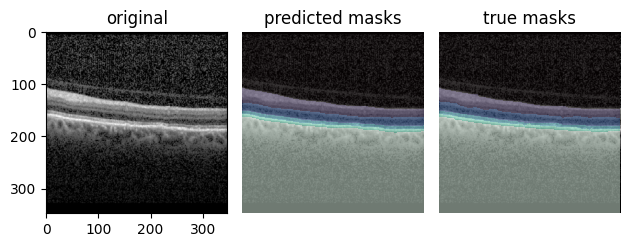

Multi-class Dice Similarity Coefficient between predicted and true masks: [0.99899429 0.96990952 0.94793767 0.88943129 0.88643216 0.99799131]


In [35]:
analysis("test_images/0001.png", "test_outputs/0001_out.png", "test_masks/0001.png", image_title="original")

# Speckle

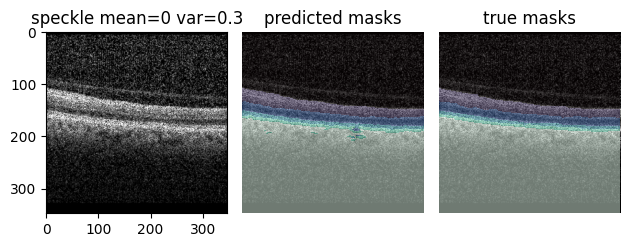

Multi-class Dice Similarity Coefficient between predicted and true masks: [0.99868338 0.9654539  0.93989758 0.85818847 0.75476027 0.99351747]


In [36]:
analysis("noisy_images/0001_speckle_m0v0.3.png", "test_outputs/0001_speckle_m0v0.3_out.png", "test_masks/0001.png", image_title="speckle mean=0 var=0.3")

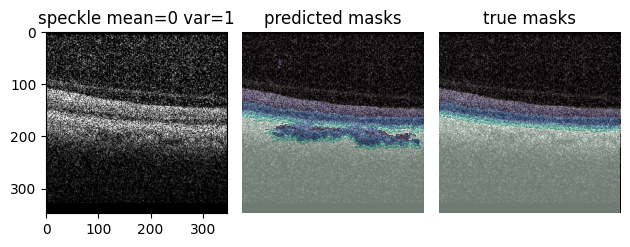

Multi-class Dice Similarity Coefficient between predicted and true masks: [0.99762099 0.88948575 0.64068072 0.63843774 0.37986952 0.92001456]


In [37]:
analysis("noisy_images/0001_speckle_m0v1.png", "test_outputs/0001_speckle_m0v1_out.png", "test_masks/0001.png", image_title="speckle mean=0 var=1")